# 07 · Finale Evaluation auf dem reservierten Testsplit

**Voraussetzung:** Modellfamilie, Augmentierung und Score-Threshold wurden in Notebook 06 ausschließlich mit Train/Validation festgelegt.

Dieses Notebook öffnet den bislang unangetasteten **Testsplit genau für die finale Evaluation**. Es verändert weder das ausgewählte Modell noch den Threshold. Detektionsausfälle (`incomplete_pair`, `not_detected`) bleiben Teil der End-to-End-Bewertung und werden nicht aus dem Nenner entfernt.

> Der Test bewertet den festgelegten Prototyp innerhalb des vorhandenen TLFS23-Splits. Er belegt keine Generalisierung auf unbekannte Personen, neue Aufnahmebedingungen oder beliebige Smartphone-Fotos.


## 1. Eingefrorene Modellentscheidung prüfen


In [1]:
from pathlib import Path
import shutil
import subprocess
import sys

import joblib
import numpy as np
import pandas as pd
from IPython.display import display 

here = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        p for p in (here, *here.parents)
        if (p / "notebooks").is_dir()
        and (p / "data").is_dir()
        and (p / "src").is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Projektordner mit notebooks/, data/ und src/ fehlt.")

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from tlfs23 import data as d
from tlfs23 import features as f
from tlfs23 import modeling as m
from tlfs23.common import paths, read_json, runtime, sha256_file, write_json

P = paths(PROJECT_ROOT)
MODEL_DIR = P["work"] / "modeling"
SELECTION_PATH = MODEL_DIR / "selected_model.json"
DECISION_PATH = P["work"] / "06_model_decision.json"
TEST_DIR = P["work"] / "final_test"
LOCK_PATH = P["work"] / "07_test_access_lock.json"

selection = read_json(SELECTION_PATH)
decision = read_json(DECISION_PATH)
selection_sha = sha256_file(SELECTION_PATH)

if decision["selection_sha256"] != selection_sha:
    raise ValueError("Die Modellentscheidung passt nicht mehr zur ausgewählten Modellversion.")
if decision["model_version"] != selection["model_version"]:
    raise ValueError("Notebook-06-Entscheidung und ausgewähltes Modell stimmen nicht überein.")

# Der in Notebook 06 verwendete Code-/Featurestand muss unverändert sein.
provenance = selection["provenance"]
if sha256_file(Path(m.__file__)) != provenance["modeling_code_sha256"]:
    raise ValueError("modeling.py wurde seit Notebook 06 verändert. Nicht mit geändertem Inferenzcode testen.")
if sha256_file(Path(f.__file__)) != provenance["features_code_sha256"]:
    raise ValueError("features.py wurde seit Notebook 06 verändert. Nicht mit geändertem Featurecode testen.")
if sha256_file(P["work"] / "05_feature_decision.json") != provenance["feature_decision_sha256"]:
    raise ValueError("Die freigegebene Featureentscheidung wurde seit Notebook 06 verändert.")

model_path = PROJECT_ROOT / selection["model_path"]
if sha256_file(model_path) != selection["model_sha256"]:
    raise ValueError("Das ausgewählte Modellartefakt wurde verändert.")


print("Modellversion:", selection["model_version"])
print("Experiment:", selection["experiment"])
print("Threshold:", selection["threshold"])
print("Test bisher geöffnet:", LOCK_PATH.exists())


Modellversion: 20261003_190248_9c16aa_rf_augmented
Experiment: rf_augmented
Threshold: 0.5
Test bisher geöffnet: True


## 2. Reservierten Testsplit prüfen

Vor der Evaluation werden ausschließlich die Metadaten des festgeschriebenen Testsplits geladen. Die Testbilder selbst werden erst im nächsten Schritt verarbeitet.


In [2]:
split_plan, split_state = d.load_split(PROJECT_ROOT)
test_plan = split_plan.loc[split_plan["split"].eq("test")].copy()

print("Testbilder:", len(test_plan))
display(
    test_plan.groupby("category")
    .size()
    .rename("n_images")
    .reset_index()
)


Testbilder: 12450


,category,n_images
0,ayudha,50
1,background,100
2,mei,900
3,uyir,600
4,uyirmei,10800


## 3. Finale Holdout-Evaluation

Beim ersten Lauf wird der reservierte Testsplit für die festgeschriebene Modellauswahl geöffnet und durch einen Lock geschützt. Bei späteren Ausführungen werden ausschließlich die bereits gespeicherten Testergebnisse geladen. Ein erneutes Tuning ist nicht vorgesehen.


In [3]:
RUN_FINAL_TEST = True

metrics = None
predictions = None
test_rows = None
test_feature_dir = None

if LOCK_PATH.exists():
    lock = read_json(LOCK_PATH)
    if lock["selection_sha256"] != selection_sha:
        raise RuntimeError(
            "Der Holdout wurde bereits für eine andere Modellauswahl geöffnet. "
            "Nicht als neuen unabhängigen Test verwenden."
        )

if not RUN_FINAL_TEST:
    print("Test bleibt gesperrt. Für die finale Auswertung RUN_FINAL_TEST = True setzen.")
else:
    TEST_DIR.mkdir(parents=True, exist_ok=True)

    metrics_path = TEST_DIR / "metrics.json"
    predictions_path = TEST_DIR / "predictions.csv"
    state_path = TEST_DIR / "07_test_state.json"

    # Bereits vollständig ausgewerteter Test: nur gespeicherte Resultate laden.
    if metrics_path.exists() and predictions_path.exists() and state_path.exists():
        state = read_json(state_path)
        if state["selection_sha256"] != selection_sha:
            raise RuntimeError("Gespeicherte Testergebnisse gehören zu einer anderen Modellauswahl.")
        metrics = read_json(metrics_path)
        predictions = pd.read_csv(predictions_path, keep_default_na=False)
        predictions["accepted"] = predictions["accepted"].astype(str).str.lower().isin(["true", "1"])
        test_feature_dir = PROJECT_ROOT / state["feature_directory"]
        test_rows = pd.read_csv(test_feature_dir / "rows.csv", keep_default_na=False)
        print("Gespeicherte finale Testergebnisse geladen; kein neuer Testlauf gestartet.")

    else:
        if not LOCK_PATH.exists():
            write_json(
                LOCK_PATH,
                {
                    "selection_sha256": selection_sha,
                    "model_version": selection["model_version"],
                    "split_sha256": split_state["split_sha256"],
                    "purpose": "final_holdout_evaluation",
                },
            )

        feature_decision = read_json(P["work"] / "05_feature_decision.json")
        config = feature_decision["config"]

        test_samples = f.samples(test_plan, augment_train=False, seed=42)
        if test_samples["variant"].ne("original").any():
            raise ValueError("Der Testsplit darf nicht augmentiert werden.")

        f.preflight(PROJECT_ROOT, config)
        test_rows, test_feature_dir = f.run_extraction(
            PROJECT_ROOT,
            test_samples,
            config,
            name="final_test",
            chunk_size=128,
            timeout=300,
            allow_holdout=True,
        )

        X_test = np.load(test_feature_dir / "features.npy", mmap_mode="r")
        if X_test.shape != (len(test_rows), len(f.FEATURE_NAMES)):
            raise ValueError("Test-Featurematrix ist nicht korrekt ausgerichtet.")

        valid = test_rows["status"].eq("ok").to_numpy()
        if not np.isfinite(X_test[valid]).all() or not np.isnan(X_test[~valid]).all():
            raise ValueError("Test-Features passen nicht zum Detektionsstatus.")

        bundle = joblib.load(model_path)
        if bundle["model_version"] != selection["model_version"]:
            raise ValueError("Geladenes Modell entspricht nicht der festgeschriebenen Auswahl.")
        if list(bundle["feature_names"]) != list(f.FEATURE_NAMES):
            raise ValueError("Feature-Schema von Modell und Notebook 05 stimmt nicht überein.")

        predictions = m.predict_heads(
            bundle,
            test_rows,
            X_test,
            threshold=float(selection["threshold"]),
        )
        metrics = m.evaluate_predictions(predictions, bundle["supported_characters"])
        metrics.update(
            {
                "model_version": selection["model_version"],
                "experiment": selection["experiment"],
                "threshold": float(selection["threshold"]),
                "validation_target_met": bool(selection["validation_target_met"]),
                "n_test_detection_failures": int(test_rows["status"].ne("ok").sum()),
                "result_status": "prototype_holdout_evaluation",
            }
        )

        predictions.to_csv(predictions_path, index=False)
        f.detection_summary(test_rows).to_csv(TEST_DIR / "detection_summary.csv", index=False)
        write_json(metrics_path, metrics)
        write_json(
            state_path,
            {
                "selection_sha256": selection_sha,
                "model_sha256": selection["model_sha256"],
                "split_sha256": split_state["split_sha256"],
                "feature_directory": test_feature_dir.relative_to(PROJECT_ROOT).as_posix(),
                "feature_metadata_sha256": sha256_file(test_feature_dir / "metadata.json"),
                "features_code_sha256": sha256_file(Path(f.__file__)),
                "modeling_code_sha256": sha256_file(Path(m.__file__)),
                "n_test_rows": len(test_rows),
            },
        )

        print("Finaler Test durchgeführt und festgeschrieben.")

    display(pd.Series(metrics, name="value").to_frame())


Gespeicherte finale Testergebnisse geladen; kein neuer Testlauf gestartet.


,value
n_inputs,12450
n_sign_inputs,12350
n_background_inputs,100
e2e_macro_f1,0.742225
e2e_sign_accuracy,0.62081
sign_coverage,0.648907
accepted_sign_accuracy,0.956701
n_accepted_signs,8014
background_false_accept_rate,0.0
background_explicit_no_sign_rate,0.18


## 4. End-to-End-Leistung

Die finale Bewertung unterscheidet zwischen Detektionsleistung, Klassifikation bei erfolgreicher Zwei-Hand-Erkennung und der vollständigen End-to-End-Leistung. Detektionsfehler bleiben Teil der Gesamtbewertung.

In [4]:
if predictions is not None:
    key_metrics = [
        "e2e_macro_f1",
        "e2e_sign_accuracy",
        "detected_sign_macro_f1",
        "detected_sign_accuracy",
        "sign_coverage",
        "accepted_sign_accuracy",
        "two_hand_rate_signs",
        "background_false_accept_rate",
        "background_explicit_no_sign_rate",
        "reject_rate",
    ]
    display(
        pd.Series({k: metrics.get(k) for k in key_metrics}, name="value")
        .to_frame()
    )

    display(pd.read_csv(TEST_DIR / "detection_summary.csv"))


,value
e2e_macro_f1,0.742225
e2e_sign_accuracy,0.620810
detected_sign_macro_f1,0.895452
detected_sign_accuracy,0.855024
sign_coverage,0.648907
accepted_sign_accuracy,0.956701
two_hand_rate_signs,0.726073
background_false_accept_rate,0.000000
background_explicit_no_sign_rate,0.180000
reject_rate,0.354859


,category,variant,n_images,n_two_hands,n_one_hand,n_no_hand,n_errors,median_ms,p95_ms,two_hand_rate
0,ayudha,original,50,33,5,12,0,30.927042,42.852915,0.660000
1,background,original,100,18,4,78,0,25.380438,44.316799,0.180000
2,mei,original,900,634,165,101,0,31.332604,46.587994,0.704444
3,uyir,original,600,389,136,75,0,31.305395,51.482302,0.648333
4,uyirmei,original,10800,7911,1620,1269,0,31.137896,45.690508,0.732500


## 5. Finale Fehlerartefakte erzeugen

Die vollständige Zeichen-Konfusionsmatrix wird als CSV gespeichert, weil eine 248-Klassen-Grafik kaum lesbar wäre. Zusätzlich werden ein Classification Report und die häufigsten Fehlertypen gespeichert.


In [5]:
if predictions is not None:
    from sklearn.metrics import classification_report, confusion_matrix

    bundle = joblib.load(model_path)
    sign_labels = list(bundle["supported_characters"])
    labels_all = [*sign_labels, m.BG, m.REJECT]

    report = classification_report(
        predictions["character"],
        predictions["predicted_character"],
        labels=labels_all,
        output_dict=True,
        zero_division=0,
    )
    pd.DataFrame(report).T.to_csv(TEST_DIR / "classification_report.csv")

    matrix = confusion_matrix(
        predictions["character"],
        predictions["predicted_character"],
        labels=labels_all,
    )
    pd.DataFrame(matrix, index=labels_all, columns=labels_all).to_csv(
        TEST_DIR / "character_confusion_matrix.csv"
    )

    errors = predictions.loc[
        predictions["character"].ne(m.BG)
        & predictions["character"].ne(predictions["predicted_character"])
    ].copy()

    top_errors = (
        errors.groupby(["character", "predicted_character", "reason"])
        .size()
        .sort_values(ascending=False)
        .rename("n")
        .reset_index()
    )
    top_errors.to_csv(TEST_DIR / "top_errors.csv", index=False)

    print("Fehlerhafte Zeichen-Vorhersagen:", len(errors))
    display(top_errors.head(10))


Fehlerhafte Zeichen-Vorhersagen: 4683


,character,predicted_character,reason,n
0,ந,__reject__,below_score_threshold,22
1,அ,__reject__,incomplete_pair,21
2,ச்,__reject__,incomplete_pair,20
3,ணோ,__reject__,incomplete_pair,20
4,ய்,__reject__,incomplete_pair,20
5,லெ,__reject__,incomplete_pair,19
6,இ,__reject__,not_detected,19
7,ஊ,__reject__,incomplete_pair,19
8,ஙீ,__reject__,not_detected,19
9,ணை,__reject__,incomplete_pair,19


## 6. Komponentenfehler visualisieren

Für Uyir, Mei und Uyirmei werden Vokal- und Konsonantenkomponenten separat dargestellt. Ein vom Threshold zurückgewiesenes Zeichen erscheint als `__reject__`.


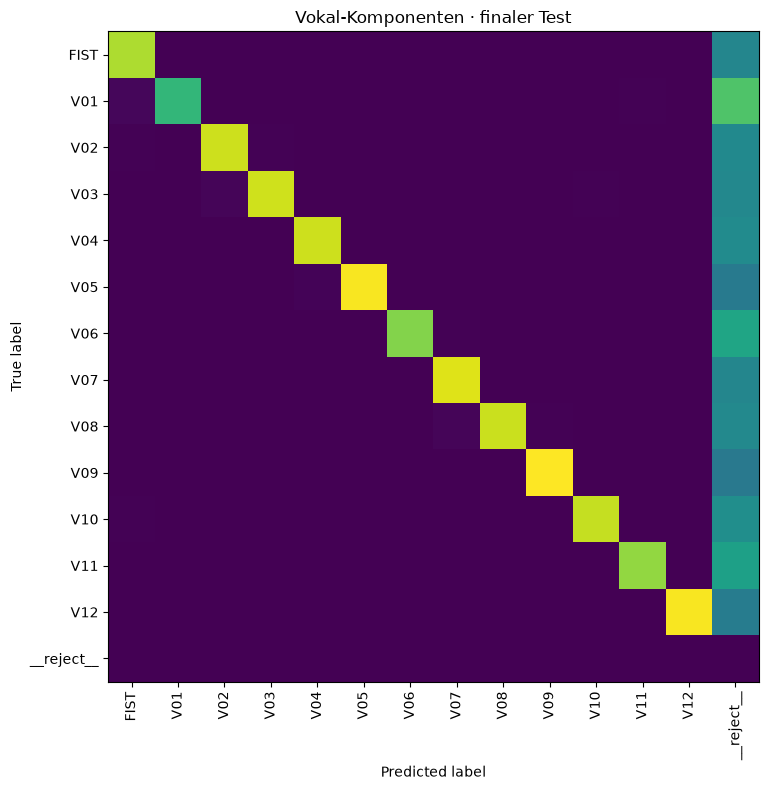

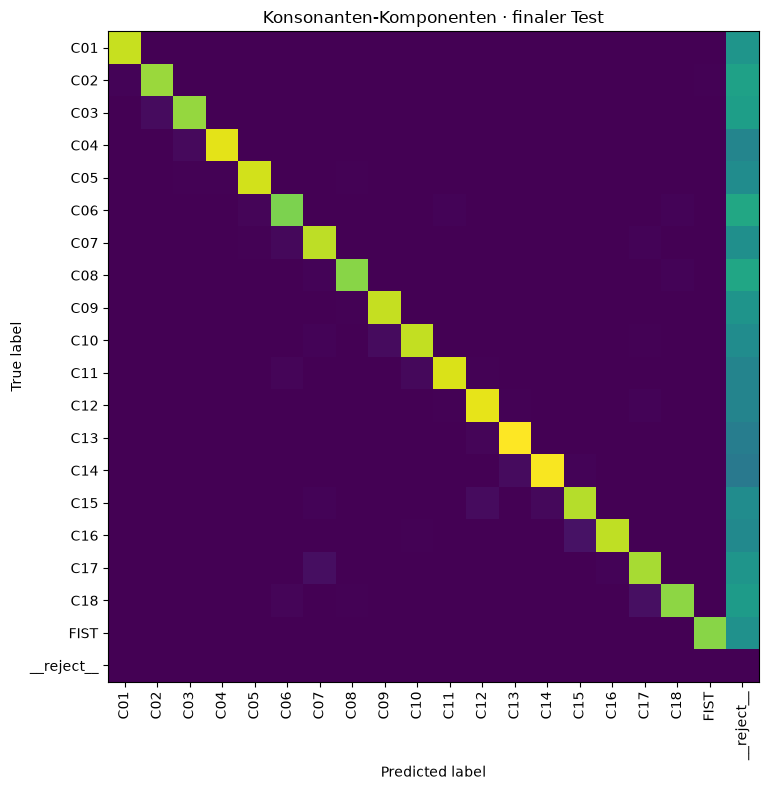

In [6]:
if predictions is not None:
    import matplotlib.pyplot as plt
    from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

    FIG_DIR = TEST_DIR / "figures"
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    regular = predictions.loc[predictions["category"].isin(m.COMPONENT_TYPES)].copy()

    for target, pred_col, title, filename in [
        ("vowel_target", "pred_vowel", "Vokal-Komponenten · finaler Test", "vowel_confusion.png"),
        ("consonant_target", "pred_consonant", "Konsonanten-Komponenten · finaler Test", "consonant_confusion.png"),
    ]:
        true = regular[target].astype(str)
        found = regular[pred_col].astype(str).where(regular["accepted"], m.REJECT)
        labels = sorted(set(true)) + [m.REJECT]
        cm = confusion_matrix(true, found, labels=labels)

        fig, ax = plt.subplots(figsize=(9, 8))
        ConfusionMatrixDisplay(cm, display_labels=labels).plot(
            ax=ax,
            xticks_rotation=90,
            include_values=False,
            colorbar=False,
        )
        ax.set_title(title)
        fig.tight_layout()
        fig.savefig(FIG_DIR / filename, dpi=150)
        plt.show()
        plt.close(fig)


## 7. Ausgewählte Fehler visuell prüfen

Nach Abschluss der Holdout-Evaluation werden einige Fehlvorhersagen exemplarisch mit Landmark-Overlay betrachtet. Diese Sichtprüfung dient ausschließlich der Fehleranalyse und beeinflusst Modell oder Threshold nicht mehr.

,relative_path,character,predicted_character,score,status,reason
1,143/img_684.jpg,மு,__reject__,0.445789,ok,below_score_threshold
3,238/img_462.jpg,னீ,__reject__,0.300010,ok,below_score_threshold
5,175/img_569.jpg,ல,__reject__,0.000000,not_detected,not_detected
10,109/img_924.jpg,தெ,__reject__,0.000000,not_detected,not_detected


**மு | uyirmei | original**  
Status: `ok`, Haende: 2, Retry: False

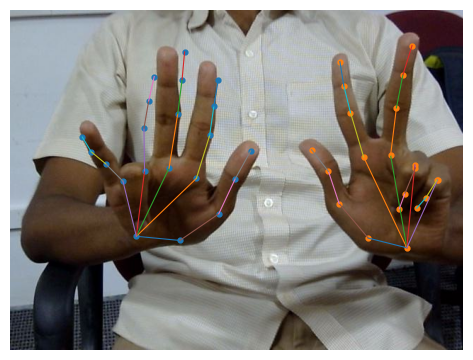

**னீ | uyirmei | original**  
Status: `ok`, Haende: 2, Retry: False

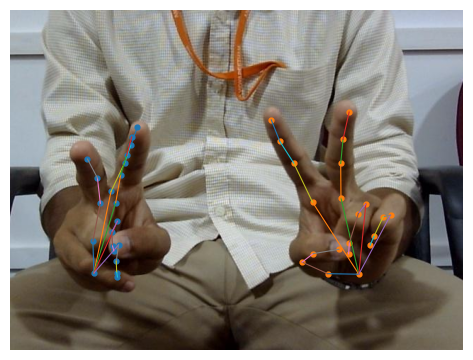

**ல | uyirmei | original**  
Status: `not_detected`, Haende: 0, Retry: True

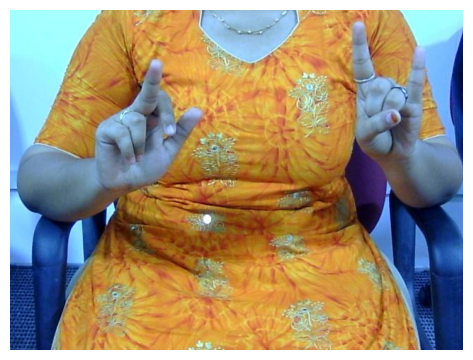

**தெ | uyirmei | original**  
Status: `not_detected`, Haende: 0, Retry: True

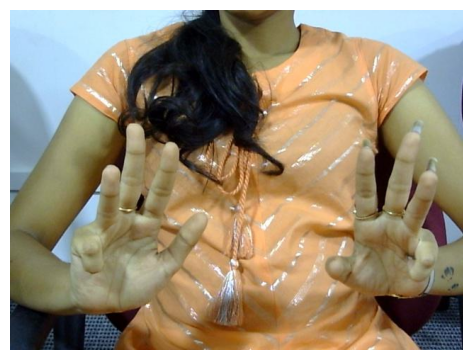

In [7]:
if predictions is not None and test_rows is not None and test_feature_dir is not None:
    error_indices = predictions.index[
        predictions["character"].ne(m.BG)
        & predictions["character"].ne(predictions["predicted_character"])
    ][:4]

    if len(error_indices):
        display(
            predictions.loc[
                error_indices,
                [
                    "relative_path",
                    "character",
                    "predicted_character",
                    "score",
                    "status",
                    "reason",
                ],
            ]
        )
        f.show_landmarks(
            PROJECT_ROOT,
            test_rows.loc[error_indices],
            test_feature_dir,
            count=min(4, len(error_indices)),
        )
    else:
        print("Keine Zeichenfehler für die visuelle Prüfung gefunden.")


## 8. Finales Inferenzpaket exportieren

Das Paket enthält das ausgewählte Random-Forest-Modell, den freigegebenen MediaPipe-Detektor, Labelschema, Feature-/Modellcode, Auswahlentscheidung, finale Testmetriken und Prüfsummen. Es dient anschließend als Basis für die lokale Demo/API.


In [8]:
if metrics is not None:
    EXPORT_DIR = PROJECT_ROOT / "models" / "export" / selection["model_version"]
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)

    detector_path = f.model_path(PROJECT_ROOT)
    label_schema_path = P["manifests"] / "label_schema.csv"

    files_to_copy = {
        model_path: EXPORT_DIR / "model.joblib",
        detector_path: EXPORT_DIR / "hand_landmarker.task",
        Path(f.__file__): EXPORT_DIR / "features.py",
        Path(m.__file__): EXPORT_DIR / "modeling.py",
        Path(d.__file__): EXPORT_DIR / "data.py",
        Path(f.__file__).with_name("common.py"): EXPORT_DIR / "common.py",
        SELECTION_PATH: EXPORT_DIR / "selected_model.json",
        DECISION_PATH: EXPORT_DIR / "06_model_decision.json",
        P["work"] / "05_feature_decision.json": EXPORT_DIR / "05_feature_decision.json",
        TEST_DIR / "metrics.json": EXPORT_DIR / "test_metrics.json",
    }

    if label_schema_path.exists():
        files_to_copy[label_schema_path] = EXPORT_DIR / "label_schema.csv"

    for source, target in files_to_copy.items():
        if not source.exists():
            raise FileNotFoundError(f"Exportquelle fehlt: {source}")
        shutil.copy2(source, target)

    # Vollständiger Paketstand für reproduzierbare lokale Wiederherstellung.
    freeze = subprocess.check_output(
        [sys.executable, "-m", "pip", "freeze"],
        text=True,
    )
    (EXPORT_DIR / "requirements-snapshot.txt").write_text(freeze, encoding="utf-8")
    write_json(EXPORT_DIR / "environment.json", runtime())

    checksums = {
        file.name: sha256_file(file)
        for file in EXPORT_DIR.iterdir()
        if file.is_file() and file.name != "checksums.json"
    }
    write_json(EXPORT_DIR / "checksums.json", checksums)

    # Integritätsprüfung direkt nach dem Export.
    for name, expected in read_json(EXPORT_DIR / "checksums.json").items():
        if sha256_file(EXPORT_DIR / name) != expected:
            raise ValueError(f"Exportdatei verändert: {name}")

    metrics["export_directory"] = EXPORT_DIR.relative_to(PROJECT_ROOT).as_posix()
    write_json(TEST_DIR / "metrics.json", metrics)

    print("Export geprüft:", EXPORT_DIR)
    print("Export geprüft:", EXPORT_DIR)
    print("Exportdateien:", len(list(EXPORT_DIR.iterdir())))

Export geprüft: /Users/sharu/Documents/DBU/tamil-finger-sign-mlops/models/export/20261003_190248_9c16aa_rf_augmented
Export geprüft: /Users/sharu/Documents/DBU/tamil-finger-sign-mlops/models/export/20261003_190248_9c16aa_rf_augmented
Exportdateien: 14


## 9. Finale Testmetriken in MLflow ergänzen

Die Testmetriken werden an den bereits in Notebook 06 ausgewählten MLflow-Run angehängt. Dadurch bleibt nachvollziehbar, welches Validierungsexperiment später genau einmal auf dem Holdout bewertet wurde.


In [9]:
if metrics is not None:
    run_id = selection.get("mlflow_run_id", "tracking-disabled")
    if run_id not in {"tracking-disabled", ""}:
        import mlflow

        tracking_uri = "sqlite:///" + (MODEL_DIR / "mlflow.db").as_posix()
        mlflow.set_tracking_uri(tracking_uri)

        with mlflow.start_run(run_id=run_id):
            mlflow.log_metrics(
                {
                    f"test_{key}": float(value)
                    for key, value in metrics.items()
                    if isinstance(value, (int, float, np.integer, np.floating))
                    and not isinstance(value, bool)
                    and np.isfinite(value)
                }
            )
            for artifact in [
                TEST_DIR / "metrics.json",
                TEST_DIR / "detection_summary.csv",
                TEST_DIR / "top_errors.csv",
                TEST_DIR / "classification_report.csv",
                TEST_DIR / "character_confusion_matrix.csv",
            ]:
                if artifact.exists():
                    mlflow.log_artifact(str(artifact), artifact_path="final_test")

        print("Finale Testmetriken wurden zum ausgewählten MLflow-Run hinzugefügt.")
    else:
        print("MLflow-Tracking war für dieses Experiment deaktiviert.")


/Users/sharu/Documents/DBU/tamil-finger-sign-mlops/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Finale Testmetriken wurden zum ausgewählten MLflow-Run hinzugefügt.


## 10. Abschluss von Notebook 07

Nach diesem Notebook stehen bereit:

- eingefrorene Modellentscheidung aus Notebook 06,
- einmalige End-to-End-Evaluation auf dem reservierten Testsplit,
- Detektions- und Klassifikationsmetriken,
- Fehleranalyse und Konfusionsartefakte,
- MLflow-Verknüpfung,
- versioniertes lokales Inferenzpaket mit Prüfsummen.

**Als Nächstes:** eine lokale Inferenzfunktion für eigene JPG/PNG-Dateien, danach eine kleine Upload-Demo/API. Diese eigenen Fotos sind zusätzliche Demonstrationsdaten und werden nicht zur nachträglichen Optimierung der berichteten Holdout-Metriken verwendet.
